Cài đặt thư viện

In [1]:
!pip install -q librosa soundfile tensorflow matplotlib seaborn scikit-learn

 Import & cấu hình

In [2]:
import os, pathlib, random, warnings
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

# ── Cấu hình chung ──────────────────────────────────────────────
SAMPLE_RATE   = 16000
DURATION      = 1        # giây
N_MFCC        = 40       # số hệ số MFCC
HOP_LENGTH    = 320      # 20 ms hop
N_FFT         = 512
N_FRAMES      = 49       # ceil(16000 / 320) ≈ 50 → pad/crop về 49

CLASSES = ["bat_den", "tat_den", "bat_quat", "tat_quat",
           "bat_het", "tat_het", "unknown"]
NUM_CLASSES = len(CLASSES)
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

# Đường dẫn dataset trên Kaggle
DATA_DIR = pathlib.Path("/kaggle/input/datasets/timmiemira182/speech/dataset_1s")  # ← đổi tên

2026-04-20 10:32:59.154416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776681179.369415      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776681179.437888      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776681179.970144      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776681179.970183      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776681179.970186      55 computation_placer.cc:177] computation placer alr

Tiền xử lý audio → MFCC

In [3]:
def load_audio(path):
    """Load file âm thanh, chuẩn hoá về 16kHz mono 1s."""
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=DURATION)
    target = SAMPLE_RATE * DURATION
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]
    return y.astype(np.float32)


def extract_mfcc(y, n_mfcc=N_MFCC):
    """Trích xuất MFCC + delta + delta-delta → shape (3, n_mfcc, n_frames)."""
    mfcc  = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=n_mfcc,
                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat = np.stack([mfcc, delta, delta2], axis=0)          # (3, 40, T)

    # Cắt / pad về đúng N_FRAMES
    T = feat.shape[2]
    if T < N_FRAMES:
        feat = np.pad(feat, ((0,0),(0,0),(0, N_FRAMES - T)))
    else:
        feat = feat[:, :, :N_FRAMES]

    # Normalize per-sample
    feat = (feat - feat.mean()) / (feat.std() + 1e-6)
    return feat.astype(np.float32)                          # (3, 40, 49)

Data augmentation

In [4]:
def augment(y, sr=SAMPLE_RATE):
    """Áp dụng ngẫu nhiên một số kỹ thuật augmentation."""
    aug_list = []

    # 1. Time shift ±200ms
    shift = random.randint(-3200, 3200)
    aug_list.append(np.roll(y, shift))

    # 2. Thêm Gaussian noise (SNR 10–30 dB)
    snr  = random.uniform(10, 30)
    rms  = np.sqrt(np.mean(y**2)) + 1e-8
    noise_amp = rms / (10 ** (snr / 20))
    aug_list.append(y + noise_amp * np.random.randn(len(y)).astype(np.float32))

    # 3. Pitch shift ±2 semitone
    n_steps = random.uniform(-2, 2)
    aug_list.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps))

    # 4. Speed perturbation 0.9–1.1×
    rate = random.uniform(0.9, 1.1)
    y_stretch = librosa.effects.time_stretch(y, rate=rate)
    target = SAMPLE_RATE * DURATION
    if len(y_stretch) < target:
        y_stretch = np.pad(y_stretch, (0, target - len(y_stretch)))
    aug_list.append(y_stretch[:target])

    # 5. Volume scaling 0.5–1.5×
    aug_list.append(y * random.uniform(0.5, 1.5))

    return aug_list   # 5 mẫu mới từ 1 mẫu gốc


def build_dataset(data_dir, augment_data=True):
    """Duyệt thư mục, load và augment toàn bộ dataset."""
    X, y_labels = [], []
    for cls in CLASSES:
        cls_dir = data_dir / cls
        if not cls_dir.exists():
            print(f"[WARN] Không tìm thấy: {cls_dir}")
            continue
        files = list(cls_dir.glob("*.wav"))
        print(f"  {cls:12s}: {len(files)} files")
        for fp in files:
            audio = load_audio(fp)
            # Mẫu gốc
            X.append(extract_mfcc(audio))
            y_labels.append(CLASS2IDX[cls])
            # Augmented (chỉ áp dụng cho lớp không phải unknown)
            if augment_data and cls != "unknown":
                for aug_audio in augment(audio):
                    X.append(extract_mfcc(aug_audio))
                    y_labels.append(CLASS2IDX[cls])

    X = np.array(X, dtype=np.float32)        # (N, 3, 40, 49)
    y_labels = np.array(y_labels, dtype=np.int32)
    print(f"\nTổng số mẫu sau augment: {len(X)}")
    return X, y_labels


print("Đang load dataset...")
X, y = build_dataset(DATA_DIR)
print(f"Shape: X={X.shape}, y={y.shape}")

Đang load dataset...
  bat_den     : 200 files
  tat_den     : 200 files
  bat_quat    : 200 files
  tat_quat    : 200 files
  bat_het     : 200 files
  tat_het     : 200 files
  unknown     : 200 files

Tổng số mẫu sau augment: 7400
Shape: X=(7400, 3, 40, 49), y=(7400,)


Chia train/val/test

In [5]:
# 70% train · 15% val · 15% test (stratified)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# TensorFlow cần channels_last: (N, 40, 49, 3)
def to_channels_last(X):
    return np.transpose(X, (0, 2, 3, 1))   # (N, 3, 40, 49) → (N, 40, 49, 3)

X_train = to_channels_last(X_train)
X_val   = to_channels_last(X_val)
X_test  = to_channels_last(X_test)
print(f"Input shape: {X_train.shape[1:]}")  # (40, 49, 3)

# tf.data pipeline
BATCH = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(2048).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)

Train: 5180  Val: 1110  Test: 1110
Input shape: (40, 49, 3)


I0000 00:00:1776681300.596098      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776681300.601920      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Kiến trúc DS-CNN

In [6]:
def depthwise_block(x, filters, stride=1, name="dw"):
    """Depthwise Separable Conv + BN + ReLU (chuẩn MobileNet-style)."""
    x = layers.DepthwiseConv2D(kernel_size=3, strides=stride,
                               padding="same", use_bias=False,
                               name=f"{name}_dw")(x)
    x = layers.BatchNormalization(name=f"{name}_dw_bn")(x)
    x = layers.ReLU(name=f"{name}_dw_relu")(x)
    x = layers.Conv2D(filters, kernel_size=1, use_bias=False,
                      name=f"{name}_pw")(x)
    x = layers.BatchNormalization(name=f"{name}_pw_bn")(x)
    x = layers.ReLU(name=f"{name}_pw_relu")(x)
    return x


def build_dscnn(input_shape=(40, 49, 3), num_classes=NUM_CLASSES):
    """
    DS-CNN nhỏ gọn cho keyword spotting trên ESP32-S3.
    ~30K parameters, <50KB sau int8 quantization.
    """
    inp = layers.Input(shape=input_shape, name="input")

    # Stem conv (standard)
    x = layers.Conv2D(32, kernel_size=3, strides=2,
                      padding="same", use_bias=False, name="stem_conv")(inp)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)

    # Depthwise separable blocks
    x = depthwise_block(x, 32, stride=1, name="dw1")
    x = depthwise_block(x, 64, stride=2, name="dw2")
    x = depthwise_block(x, 64, stride=1, name="dw3")
    x = depthwise_block(x, 64, stride=1, name="dw4")

    # Global average pooling
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="drop")(x)

    # Classifier head
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inp, out, name="DS_CNN_KWS")
    return model


model = build_dscnn()
model.summary()

# Đếm params
total = model.count_params()
print(f"\nTotal params: {total:,}")
print(f"Ước tính kích thước float32: {total * 4 / 1024:.1f} KB")
print(f"Ước tính kích thước int8:    {total / 1024:.1f} KB")

Model: "DS_CNN_KWS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 49, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv2D)              │ (None, 20, 25, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 20, 25, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu (ReLU)                │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_dw (DepthwiseConv2D)        │ (None, 20, 25, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_dw_bn (BatchNormalization)  │ (None, 20, 25, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_dw_relu (ReLU)              │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_pw (Conv2D)                 │ (None, 20, 25, 32)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_pw_bn (BatchNormalization)  │ (None, 20, 25, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw1_pw_relu (ReLU)              │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_dw (DepthwiseConv2D)        │ (None, 10, 13, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_dw_bn (BatchNormalization)  │ (None, 10, 13, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_dw_relu (ReLU)              │ (None, 10, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_pw (Conv2D)                 │ (None, 10, 13, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_pw_bn (BatchNormalization)  │ (None, 10, 13, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw2_pw_relu (ReLU)              │ (None, 10, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_dw (DepthwiseConv2D)        │ (None, 10, 13, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_dw_bn (BatchNormalization)  │ (None, 10, 13, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_dw_relu (ReLU)              │ (None, 10, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_pw (Conv2D)                 │ (None, 10, 13, 64)     │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_pw_bn (BatchNormalization)  │ (None, 10, 13, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw3_pw_relu (ReLU)              │ (None, 10, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw4_dw (DepthwiseConv2D)        │ (None, 10, 13, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw4_dw_bn (BatchNormalization)  │ (None, 10, 13, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dw4_dw_relu (ReLU)              │ (None, 10, 13, 64)     │             

 Total params: 16,103 (62.90 KB)

 Trainable params: 15,207 (59.40 KB)

 Non-trainable params: 896 (3.50 KB)


Total params: 16,103
Ước tính kích thước float32: 62.9 KB
Ước tính kích thước int8:    15.7 KB


Training

In [7]:
# Class weights để xử lý imbalance (unknown thường nhiều hơn)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = dict(enumerate(cw))
print("Class weights:", {CLASSES[k]: f"{v:.2f}" for k, v in class_weight.items()})

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
cb_list = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=15,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=class_weight,
    callbacks=cb_list,
    verbose=1
)

Class weights: {'bat_den': '0.88', 'tat_den': '0.88', 'bat_quat': '0.88', 'tat_quat': '0.88', 'bat_het': '0.88', 'tat_het': '0.88', 'unknown': '5.29'}
Epoch 1/100


I0000 00:00:1776681307.566055     142 service.cc:152] XLA service 0x79b22c002b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776681307.566096     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776681307.566100     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776681308.389685     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776681315.455574     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1964 - loss: 1.8705
Epoch 1: val_accuracy improved from -inf to 0.16216, saving model to best_model.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.1968 - loss: 1.8695 - val_accuracy: 0.1622 - val_loss: 1.9257 - learning_rate: 0.0010
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5057 - loss: 1.2682
Epoch 2: val_accuracy did not improve from 0.16216
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5062 - loss: 1.2673 - val_accuracy: 0.1622 - val_loss: 1.9421 - learning_rate: 0.0010
Epoch 3/100
159/162 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7613 - loss: 0.7743
Epoch 3: val_accuracy improved from 0.16216 to 0.48739, saving model to best_model.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7619 - loss: 0.7726 - val_accuracy: 0.4874 - val_loss: 1.3549 - learning_rate: 0.0010
Epoch 4/100
156/162 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8459 - loss: 0.5100
Epoch 4: val

Visualize training

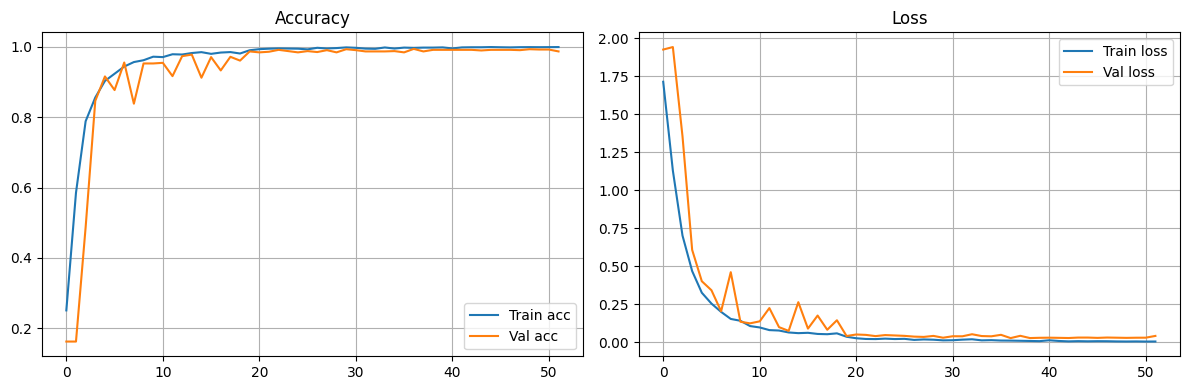

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"],   label="Train acc")
ax1.plot(history.history["val_accuracy"], label="Val acc")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True)

ax2.plot(history.history["loss"],   label="Train loss")
ax2.plot(history.history["val_loss"], label="Val loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

Đánh giá & Confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
              precision    recall  f1-score   support

     bat_den       0.99      0.99      0.99       180
     tat_den       0.99      0.99      0.99       180
    bat_quat       1.00      0.99      1.00       180
    tat_quat       0.99      1.00      1.00       180
     bat_het       0.98      0.99      0.99       180
     tat_het       0.99      0.98      0.99       180
     unknown       1.00      1.00      1.00        30

    accuracy                           0.99      1110
   macro avg       0.99      0.99      0.99      1110
weighted avg       0.99      0.99      0.99      1110



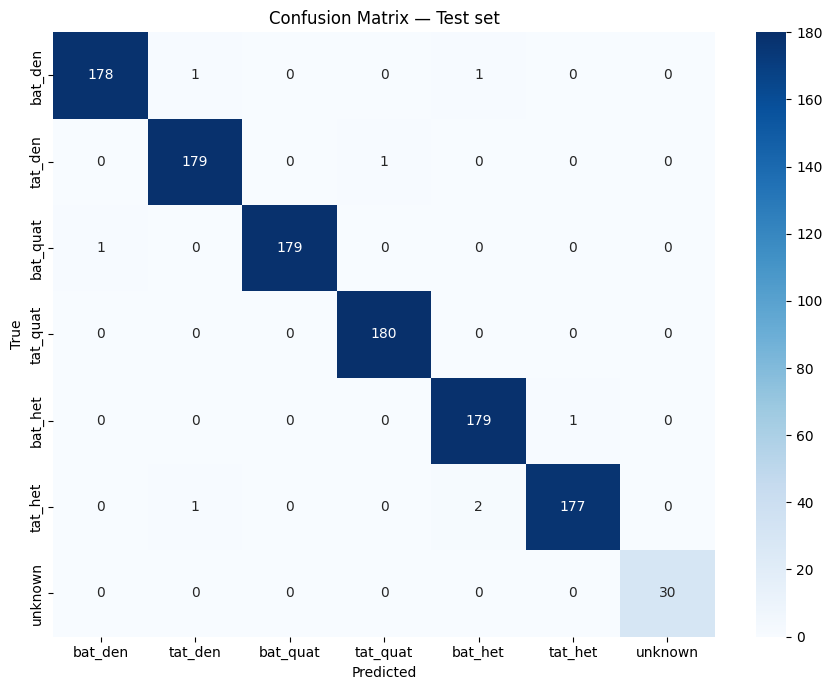


Test accuracy: 99.28%


In [9]:
# Load best model
model = tf.keras.models.load_model("best_model.keras")

y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("=" * 55)
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("=" * 55)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Accuracy tổng
acc = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\nTest accuracy: {acc*100:.2f}%")

Convert TFLite int8 (quantization)

In [10]:
def representative_dataset():
    """Cung cấp dữ liệu hiệu chỉnh cho full integer quantization."""
    for i in range(min(200, len(X_train))):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]


# Full int8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

tflite_path = "kws_model_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"TFLite int8 model size: {size_kb:.1f} KB")
assert size_kb < 200, "Model quá lớn cho ESP32-S3! Giảm số filter."

INFO:tensorflow:Assets written to: /tmp/tmpjxxis47a/assets


INFO:tensorflow:Assets written to: /tmp/tmpjxxis47a/assets


Saved artifact at '/tmp/tmpjxxis47a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 49, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133810310934608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310936144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310935952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310935568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310936720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310935184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310936336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310936528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310934992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310937680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133810310937104: Tensor

W0000 00:00:1776681374.011499      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776681374.011544      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776681374.037897      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite int8 model size: 33.5 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Kiểm tra TFLite model

In [11]:
interp = tf.lite.Interpreter(model_path=tflite_path)
interp.allocate_tensors()

inp_det = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
print("Input  dtype:", inp_det["dtype"], " shape:", inp_det["shape"])
print("Output dtype:", out_det["dtype"], " shape:", out_det["shape"])

# Scale / zero_point để dequantize
in_scale, in_zp   = inp_det["quantization"]
out_scale, out_zp = out_det["quantization"]

correct = 0
for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    # Quantize input
    sample_int8 = (sample / in_scale + in_zp).astype(np.int8)
    interp.set_tensor(inp_det["index"], sample_int8)
    interp.invoke()
    out_int8 = interp.get_tensor(out_det["index"])
    out_float = (out_int8.astype(np.float32) - out_zp) * out_scale
    pred = np.argmax(out_float)
    if pred == y_test[i]:
        correct += 1

tflite_acc = correct / len(X_test) * 100
print(f"\nTFLite int8 accuracy: {tflite_acc:.2f}%")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Input  dtype: <class 'numpy.int8'>  shape: [ 1 40 49  3]
Output dtype: <class 'numpy.int8'>  shape: [1 7]

TFLite int8 accuracy: 95.50%


Xuất ra C array cho ESP32-S3

In [12]:
# Phương pháp 1: xxd (nếu chạy trên Linux / Kaggle)
!xxd -i kws_model_int8.tflite > kws_model.h
!head -5 kws_model.h

# Phương pháp 2: Python thuần (portable hơn)
def tflite_to_c_array(tflite_path, out_path, array_name="kws_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    lines = ["#pragma once", "#include <stdint.h>", "",
             f"const uint8_t {array_name}[] = {{"]
    row = []
    for i, b in enumerate(data):
        row.append(f"0x{b:02x}")
        if len(row) == 16:
            lines.append("  " + ", ".join(row) + ",")
            row = []
    if row:
        lines.append("  " + ", ".join(row))
    lines.append("};")
    lines.append(f"const unsigned int {array_name}_len = {len(data)};")
    with open(out_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Đã xuất: {out_path}  ({len(data)} bytes)")

tflite_to_c_array("kws_model_int8.tflite", "kws_model.h")

unsigned char kws_model_int8_tflite[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x90, 0x00, 0x00, 0x00, 0x10, 0x01, 0x00, 0x00,
Đã xuất: kws_model.h  (34328 bytes)


Export toàn bộ artifacts

In [13]:
import shutil, zipfile

# Lưu scaler info (in_scale, in_zp) để dùng trong firmware
import json
quant_info = {
    "input_scale": float(in_scale),
    "input_zero_point": int(in_zp),
    "output_scale": float(out_scale),
    "output_zero_point": int(out_zp),
    "classes": CLASSES,
    "sample_rate": SAMPLE_RATE,
    "n_mfcc": N_MFCC,
    "hop_length": HOP_LENGTH,
    "n_fft": N_FFT,
    "n_frames": N_FRAMES,
    "tflite_size_kb": round(size_kb, 1),
    "tflite_acc_pct": round(tflite_acc, 2),
}
with open("quant_info.json", "w") as f:
    json.dump(quant_info, f, indent=2)

# Zip tất cả lại
with zipfile.ZipFile("esp32s3_kws.zip", "w") as z:
    for fn in ["kws_model_int8.tflite", "kws_model.h",
               "quant_info.json", "confusion_matrix.png",
               "training_history.png", "best_model.keras"]:
        if os.path.exists(fn):
            z.write(fn)

print("Xong! File esp32s3_kws.zip chứa tất cả artifacts.")
print(json.dumps(quant_info, indent=2))

Xong! File esp32s3_kws.zip chứa tất cả artifacts.
{
  "input_scale": 0.10073702037334442,
  "input_zero_point": 79,
  "output_scale": 0.00390625,
  "output_zero_point": -128,
  "classes": [
    "bat_den",
    "tat_den",
    "bat_quat",
    "tat_quat",
    "bat_het",
    "tat_het",
    "unknown"
  ],
  "sample_rate": 16000,
  "n_mfcc": 40,
  "hop_length": 320,
  "n_fft": 512,
  "n_frames": 49,
  "tflite_size_kb": 33.5,
  "tflite_acc_pct": 95.5
}


In [14]:
def export_esp_idf_files(tflite_path, array_name="kws_model_data"):
    with open(tflite_path, "rb") as f:
        data = f.read()
    n = len(data)

    # ── kws_model_data.h ──
    h = f"""#pragma once
#ifdef __cplusplus
extern "C" {{
#endif

extern const unsigned char {array_name}[];
extern const unsigned int  {array_name}_len;

#ifdef __cplusplus
}}
#endif
"""

    # ── kws_model_data.cc ── dùng dấu phẩy SAU MỖI DÒNG
    hex_rows = []
    for i in range(0, n, 12):
        chunk = data[i:i+12]
        hex_rows.append("  " + ", ".join(f"0x{b:02x}" for b in chunk) + ",")

    # Xóa dấu phẩy ở dòng CUỐI CÙNG
    if hex_rows:
        hex_rows[-1] = hex_rows[-1].rstrip(",")

    cc = f"""#include "kws_model_data.h"

const unsigned char {array_name}[] = {{
{chr(10).join(hex_rows)}
}};

const unsigned int {array_name}_len = {n};
"""

    with open("kws_model_data.h",  "w") as f: f.write(h)
    with open("kws_model_data.cc", "w") as f: f.write(cc)

    # Kiểm tra nhanh
    print(f"✓ kws_model_data.h")
    print(f"✓ kws_model_data.cc  ({n/1024:.1f} KB, {len(hex_rows)} dòng)")
    print(f"\n5 dòng đầu:")
    for row in hex_rows[:5]: print(row)
    print("...")
    print(f"\nDòng cuối: {hex_rows[-1]}")

export_esp_idf_files("kws_model_int8.tflite")

✓ kws_model_data.h
✓ kws_model_data.cc  (33.5 KB, 2861 dòng)

5 dòng đầu:
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x90, 0x00, 0x00, 0x00, 0x10, 0x01, 0x00, 0x00,
  0x84, 0x42, 0x00, 0x00, 0x94, 0x42, 0x00, 0x00, 0x6c, 0x85, 0x00, 0x00,
...

Dòng cuối:   0x03, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x03
